# Unit II — Extracting Features & Relations from Text
### Topics Covered:
1. Finding Implicit Features
2. Finding Opinion Phrases and their Polarity
3. Context-Specific Word Semantic Orientation
4. Analysis of Word and Document Frequency
5. TF-IDF
6. Zipf's Law
7. Binding TF-IDF Function
8. Subsequence Kernels for Relation Extraction
9. Capturing Relation Patterns with a String Kernel

## 🔧 Installation & Imports

In [1]:
# Install required packages (run once)
!pip install nltk pandas scikit-learn matplotlib seaborn textblob 
!pip install wordcloud scipy numpy

In [2]:
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import Counter, defaultdict
import re
import math
from itertools import combinations

# NLTK downloads
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('opinion_lexicon')
nltk.download('sentiwordnet')
nltk.download('maxent_ne_chunker')
nltk.download('words')

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, opinion_lexicon, sentiwordnet as swn, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, ne_chunk

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

from textblob import TextBlob
from scipy.stats import pearsonr
from wordcloud import WordCloud

# Plot settings
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
print('All imports successful!')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Devananthan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Devananthan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Devananthan\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Devananthan\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Devananthan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Us

All imports successful!


---
## 1. Finding Implicit Features

**Implicit features** are product/entity attributes that are not explicitly mentioned in text but can be inferred from opinion words. For example, *"This phone is heavy"* implicitly refers to the **weight** feature.

In [3]:
# --- Lexicon-Based Implicit Feature Mapping ---

# Sample product reviews
reviews = [
    "The battery drains very fast.",
    "It feels so heavy in my hand.",
    "The display is absolutely stunning.",
    "Boots up in seconds, really snappy.",
    "The lens captures incredibly sharp images.",
    "Looks premium and sleek.",
    "The device runs very hot after a few minutes.",
    "Browsing is buttery smooth."
]

# Implicit feature lexicon: opinion word -> implicit feature
implicit_feature_lexicon = {
    'heavy':   'weight',      'light':    'weight',
    'fast':    'performance', 'slow':     'performance',
    'smooth':  'performance', 'snappy':   'performance',
    'drains':  'battery',     'lasts':    'battery',
    'sharp':   'camera',      'blurry':   'camera',
    'stunning':'display',     'dim':      'display',
    'sleek':   'design',      'premium':  'design',
    'hot':     'heat',        'cool':     'heat',
    'boots':   'performance', 'freeze':   'performance'
}

def find_implicit_features(text, lexicon):
    """Identify implicit features from opinion words in the text."""
    tokens = word_tokenize(text.lower())
    found = []
    for token in tokens:
        if token in lexicon:
            found.append((token, lexicon[token]))
    return found

print("=" * 60)
print("IMPLICIT FEATURE DETECTION")
print("=" * 60)

results = []
for rev in reviews:
    features = find_implicit_features(rev, implicit_feature_lexicon)
    print(features)
    feat_str = ", ".join([f"{w}→{f}" for w, f in features]) if features else "None"
    results.append({'Review': rev, 'Implicit Features': feat_str})
    print(f"Review  : {rev}")
    print(f"Features: {feat_str}")
    print("-" * 60)


print(results)
df_implicit = pd.DataFrame(results)
df_implicit

IMPLICIT FEATURE DETECTION
[('drains', 'battery'), ('fast', 'performance')]
Review  : The battery drains very fast.
Features: drains→battery, fast→performance
------------------------------------------------------------
[('heavy', 'weight')]
Review  : It feels so heavy in my hand.
Features: heavy→weight
------------------------------------------------------------
[('stunning', 'display')]
Review  : The display is absolutely stunning.
Features: stunning→display
------------------------------------------------------------
[('boots', 'performance'), ('snappy', 'performance')]
Review  : Boots up in seconds, really snappy.
Features: boots→performance, snappy→performance
------------------------------------------------------------
[('sharp', 'camera')]
Review  : The lens captures incredibly sharp images.
Features: sharp→camera
------------------------------------------------------------
[('premium', 'design'), ('sleek', 'design')]
Review  : Looks premium and sleek.
Features: premium→design, 

,Review,Implicit Features
0,The battery drains very fast.,"drains→battery, fast→performance"
1,It feels so heavy in my hand.,heavy→weight
2,The display is absolutely stunning.,stunning→display
3,"Boots up in seconds, really snappy.","boots→performance, snappy→performance"
4,The lens captures incredibly sharp images.,sharp→camera
5,Looks premium and sleek.,"premium→design, sleek→design"
6,The device runs very hot after a few minutes.,hot→heat
7,Browsing is buttery smooth.,smooth→performance


C:\Users\Devananthan\AppData\Local\Temp\ipykernel_11516\1605899464.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=features_df, x='Feature', y='Count', palette='viridis')


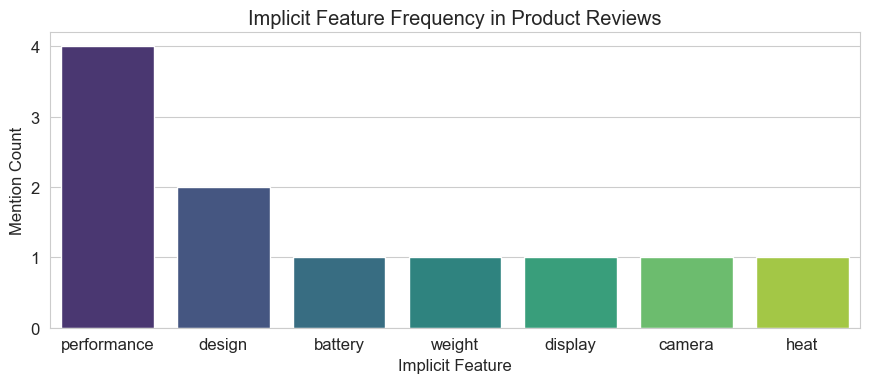

In [4]:
# --- Frequency Analysis of Implicit Features ---

feature_counts = Counter()
for rev in reviews:
    for _, feat in find_implicit_features(rev, implicit_feature_lexicon):
        feature_counts[feat] += 1

features_df = pd.DataFrame(feature_counts.items(), columns=['Feature', 'Count'])
features_df = features_df.sort_values('Count', ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(data=features_df, x='Feature', y='Count', palette='viridis')
plt.title('Implicit Feature Frequency in Product Reviews')
plt.xlabel('Implicit Feature')
plt.ylabel('Mention Count')
plt.tight_layout()
plt.show()

In [5]:
# --- Dependency-Based Implicit Feature Detection using POS tagging ---
# Technique: JJ (adjective) near NN (noun) often implies the noun as explicit, 
# but if no noun is present, the adjective implies an implicit feature.

def pos_based_implicit_feature(sentence, lexicon):
    """Use POS tagging to better detect implicit features."""
    tokens = word_tokenize(sentence)
    tagged  = pos_tag(tokens)
    opinion_words = [w for w, t in tagged if t.startswith('JJ') or t.startswith('VB')]
    nouns         = [w for w, t in tagged if t.startswith('NN')]
    implicit = []
    for ow in opinion_words:
        if ow.lower() in lexicon and not nouns:
            implicit.append((ow, lexicon[ow.lower()]))
    return tagged, opinion_words, nouns, implicit

sample = "Boots up in seconds, really snappy."
tagged, ops, nouns, impl = pos_based_implicit_feature(sample, implicit_feature_lexicon)

print(f"Sentence       : {sample}")
print(f"POS Tags       : {tagged}")
print(f"Opinion Words  : {ops}")
print(f"Nouns Found    : {nouns}")
print(f"Implicit Feats : {impl}")

Sentence       : Boots up in seconds, really snappy.
POS Tags       : [('Boots', 'NNP'), ('up', 'RP'), ('in', 'IN'), ('seconds', 'NNS'), (',', ','), ('really', 'RB'), ('snappy', 'JJ'), ('.', '.')]
Opinion Words  : ['snappy']
Nouns Found    : ['Boots', 'seconds']
Implicit Feats : []


---
## 2. Finding Opinion Phrases and Their Polarity

Opinion phrases are adjective-noun or adverb-adjective combinations carrying sentiment. We extract them and determine their polarity (positive / negative / neutral).

In [6]:
# --- Opinion Phrase Extraction using POS Patterns ---

pos_reviews = [
    "The camera quality is excellent and the battery life is very long.",
    "The screen resolution is poor and the sound quality is terrible.",
    "Amazing build quality with a stunning design.",
    "The slow processor makes multitasking frustrating.",
    "Great customer service but the delivery was really late."
]

positive_words = set(opinion_lexicon.positive())
negative_words = set(opinion_lexicon.negative())

print()

def extract_opinion_phrases(sentence):
    """Extract (adjective, noun) opinion pairs and assign polarity."""
    tokens = word_tokenize(sentence)
    tagged = pos_tag(tokens)
    phrases = []
    for i in range(len(tagged) - 1):
        word1, tag1 = tagged[i]
        word2, tag2 = tagged[i + 1]
        # Pattern: Adjective followed by Noun
        if tag1.startswith('JJ') and tag2.startswith('NN'):
            phrase = f"{word1} {word2}"
            w_lower = word1.lower()
            if w_lower in positive_words:
                polarity = 'Positive 😊'
            elif w_lower in negative_words:
                polarity = 'Negative 😞'
            else:
                polarity = 'Neutral 😐'
            phrases.append({'Phrase': phrase, 'Adjective': word1, 'Noun': word2, 'Polarity': polarity})
    return phrases

print("=" * 65)
print("OPINION PHRASE EXTRACTION WITH POLARITY")
print("=" * 65)

all_phrases = []
for rev in pos_reviews:
    phrases = extract_opinion_phrases(rev)
    print(f"\nReview: {rev}")
    if phrases:
        for p in phrases:
            print(f"  Phrase: '{p['Phrase']}' | Polarity: {p['Polarity']}")
            all_phrases.append(p)
    else:
        print("  No direct JJ+NN patterns found.")

df_phrases = pd.DataFrame(all_phrases)
print("\n")
df_phrases


OPINION PHRASE EXTRACTION WITH POLARITY

Review: The camera quality is excellent and the battery life is very long.
  No direct JJ+NN patterns found.

Review: The screen resolution is poor and the sound quality is terrible.
  No direct JJ+NN patterns found.

Review: Amazing build quality with a stunning design.
  Phrase: 'build quality' | Polarity: Neutral 😐
  Phrase: 'stunning design' | Polarity: Positive 😊

Review: The slow processor makes multitasking frustrating.
  Phrase: 'slow processor' | Polarity: Negative 😞

Review: Great customer service but the delivery was really late.
  No direct JJ+NN patterns found.




,Phrase,Adjective,Noun,Polarity
0,build quality,build,quality,Neutral 😐
1,stunning design,stunning,design,Positive 😊
2,slow processor,slow,processor,Negative 😞


TextBlob Sentiment Analysis:

                                                    Review  Polarity Score  Subjectivity    Label
The camera quality is excellent and the battery life is...           0.468         0.760 Positive
The screen resolution is poor and the sound quality is ...          -0.333         0.667 Negative
          Amazing build quality with a stunning design....           0.550         0.950 Positive
     The slow processor makes multitasking frustrating....          -0.350         0.650 Negative
Great customer service but the delivery was really late...           0.250         0.675 Positive


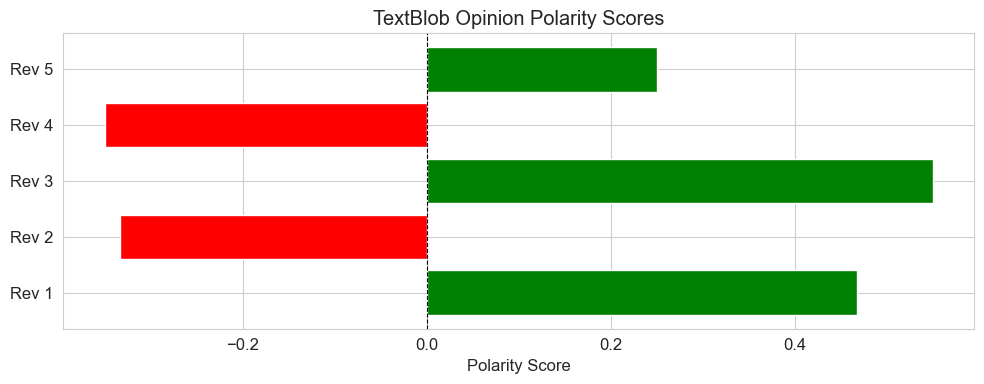

In [7]:
# --- TextBlob Sentiment Polarity for Opinion Phrases ---

def textblob_polarity(sentence):
    """Use TextBlob for sentence-level polarity score."""
    blob = TextBlob(sentence)
    score = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    if score > 0.05:
        label = 'Positive'
    elif score < -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'
    return score, subjectivity, label

records = []
for rev in pos_reviews:
    score, subj, label = textblob_polarity(rev)
    records.append({'Review': rev[:55] + '...', 'Polarity Score': round(score, 3),
                    'Subjectivity': round(subj, 3), 'Label': label})

df_tb = pd.DataFrame(records)
print("TextBlob Sentiment Analysis:\n")
print(df_tb.to_string(index=False))

# Visualize
colors = ['green' if l == 'Positive' else 'red' if l == 'Negative' else 'gray'
          for l in df_tb['Label']]
plt.figure(figsize=(10, 4))
bars = plt.barh(range(len(df_tb)), df_tb['Polarity Score'], color=colors)
plt.yticks(range(len(df_tb)), [f"Rev {i+1}" for i in range(len(df_tb))])
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Polarity Score')
plt.title('TextBlob Opinion Polarity Scores')
plt.tight_layout()
plt.show()

SentiWordNet Scores for Opinion Adjectives:
Adjective  PosScore  NegScore Orientation
excellent     1.000     0.000    Positive
     poor     0.021     0.500    Negative
  amazing     0.688     0.188    Positive
     slow     0.000     0.167    Negative
    great     0.312     0.021    Positive
 terrible     0.031     0.656    Negative
 stunning     0.188     0.344    Negative


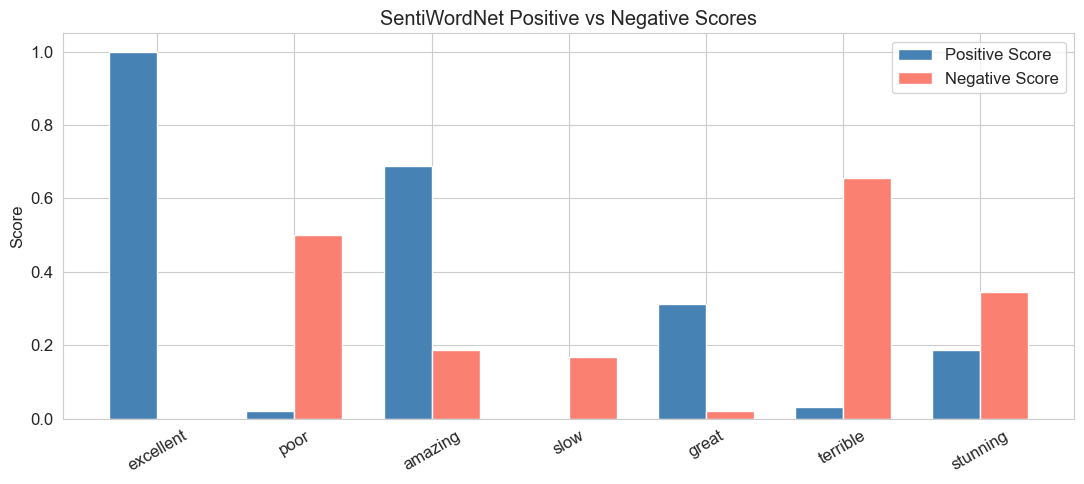

In [8]:
# --- SentiWordNet-based Opinion Phrase Polarity ---

def sentiwordnet_score(word, pos='a'):
    """Get positive and negative scores from SentiWordNet."""
    synsets = list(swn.senti_synsets(word, pos))
    if not synsets:
        return 0.0, 0.0
    pos_score = np.mean([s.pos_score() for s in synsets])
    neg_score = np.mean([s.neg_score() for s in synsets])
    return round(pos_score, 3), round(neg_score, 3)

adjectives_to_test = ['excellent', 'poor', 'amazing', 'slow', 'great', 'terrible', 'stunning']

swn_data = []
for adj in adjectives_to_test:
    p, n = sentiwordnet_score(adj, 'a')
    orientation = 'Positive' if p > n else ('Negative' if n > p else 'Neutral')
    swn_data.append({'Adjective': adj, 'PosScore': p, 'NegScore': n, 'Orientation': orientation})

df_swn = pd.DataFrame(swn_data)
print("SentiWordNet Scores for Opinion Adjectives:")
print(df_swn.to_string(index=False))

# Plot
x = np.arange(len(df_swn))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, df_swn['PosScore'], width, label='Positive Score', color='steelblue')
ax.bar(x + width/2, df_swn['NegScore'], width, label='Negative Score', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(df_swn['Adjective'], rotation=30)
ax.set_title('SentiWordNet Positive vs Negative Scores')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Context-Specific Word Semantic Orientation

Semantic Orientation (SO) of a word varies by domain context. The SO-PMI (Pointwise Mutual Information) method by Turney (2002) computes orientation based on co-occurrence with seed positive/negative words.

In [9]:
# --- SO-PMI: Context-Specific Semantic Orientation ---

# Corpus of domain-specific sentences
corpus = [
    "The battery life is excellent and long lasting.",
    "The camera quality is poor and blurry.",
    "Amazing display with vibrant colors.",
    "Horrible design and heavy weight.",
    "Fast performance and smooth operation.",
    "Slow processing speed is frustrating.",
    "Great value for money.",
    "Terrible sound quality and muffled audio.",
    "The phone heats up very fast.",
    "Lightweight and compact design.",
    "The build quality feels cheap and fragile.",
    "Outstanding camera with sharp resolution."
]

# Positive and negative seed words
positive_seeds = ['excellent', 'amazing', 'great', 'outstanding', 'fast', 'smooth']
negative_seeds = ['poor', 'horrible', 'terrible', 'slow', 'cheap', 'frustrating']

# Words to evaluate
target_words = ['vibrant', 'blurry', 'lightweight', 'fragile', 'sharp', 'muffled', 'compact', 'heavy']

def count_co_occurrence(word, seed_list, corpus_sents):
    """Count how many sentences contain both word and any seed word."""
    count = 0
    for sent in corpus_sents:
        tokens = set(word_tokenize(sent.lower()))
        if word in tokens and any(s in tokens for s in seed_list):
            count += 1
    return max(count, 1)  # Laplace smoothing

def so_pmi(word, pos_seeds, neg_seeds, corpus_sents):
    """Compute SO-PMI for a target word."""
    pos_count = count_co_occurrence(word, pos_seeds, corpus_sents)
    neg_count = count_co_occurrence(word, neg_seeds, corpus_sents)
    so = math.log2(pos_count / neg_count)
    return round(so, 4)

so_results = []
for word in target_words:
    so = so_pmi(word, positive_seeds, negative_seeds, corpus)
    orientation = 'Positive' if so > 0 else ('Negative' if so < 0 else 'Neutral')
    so_results.append({'Word': word, 'SO-PMI Score': so, 'Semantic Orientation': orientation})

df_so = pd.DataFrame(so_results).sort_values('SO-PMI Score', ascending=False)
print("Context-Specific Semantic Orientation (SO-PMI):")
print(df_so.to_string(index=False))

Context-Specific Semantic Orientation (SO-PMI):
       Word  SO-PMI Score Semantic Orientation
    vibrant           0.0              Neutral
     blurry           0.0              Neutral
lightweight           0.0              Neutral
    fragile           0.0              Neutral
      sharp           0.0              Neutral
    muffled           0.0              Neutral
    compact           0.0              Neutral
      heavy           0.0              Neutral


In [ ]:
# Visualize SO-PMI Scores
colors = ['steelblue' if s > 0 else 'tomato' for s in df_so['SO-PMI Score']]

plt.figure(figsize=(10, 5))
bars = plt.barh(df_so['Word'], df_so['SO-PMI Score'], color=colors)
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('SO-PMI Score')
plt.title('Context-Specific Semantic Orientation (SO-PMI)')
plt.legend(handles=[
    plt.Rectangle((0,0),1,1, color='steelblue', label='Positive'),
    plt.Rectangle((0,0),1,1, color='tomato', label='Negative')
])
plt.tight_layout()
plt.show()

In [11]:
# --- Context Window-Based Semantic Orientation ---
# Check if orientation changes between two different contexts (domains)

tech_context = [
    "The fast processor runs all apps smoothly.",
    "Fast charging means less waiting time.",
    "Fast network speed improves streaming."
]
food_context = [
    "The food spoils fast in hot weather.",
    "The ice cream melts fast, so eat quickly.",
    "Fast food is unhealthy but convenient."
]

def context_orientation(word, ctx_corpus, pos_seeds, neg_seeds):
    so = so_pmi(word, pos_seeds, neg_seeds, ctx_corpus)
    return so

word = 'fast'
tech_so = context_orientation(word, tech_context, positive_seeds, negative_seeds)
food_so = context_orientation(word, food_context, positive_seeds, negative_seeds)

print(f"Word: '{word}'")
print(f"  Tech Context  SO-PMI: {tech_so:+.4f} → {'Positive' if tech_so>0 else 'Negative'}")
print(f"  Food Context  SO-PMI: {food_so:+.4f} → {'Positive' if food_so>0 else 'Negative'}")
print("\n→ Same word carries different semantic orientation in different contexts!")

NameError: name 'positive_seeds' is not defined

---
## 4. Analysis of Word and Document Frequency

In [ ]:
# --- Word Frequency Analysis ---

documents = [
    "Natural language processing enables computers to understand human language.",
    "Machine learning algorithms learn from data to make predictions.",
    "Deep learning models use neural networks for language understanding.",
    "Text mining extracts information from large document collections.",
    "Sentiment analysis determines the opinion and emotion in text.",
    "Named entity recognition identifies names, dates, and locations in text.",
    "Language models predict the next word in a sequence.",
    "Information retrieval systems find relevant documents for a query."
]

# Tokenize and compute word frequency
all_tokens = []
for doc in documents:
    tokens = word_tokenize(doc.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    all_tokens.extend(tokens)

word_freq = Counter(all_tokens)
df_wf = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Frequency'])

print("Top 20 Words by Frequency:")
print(df_wf.to_string(index=False))

plt.figure(figsize=(12, 5))
sns.barplot(data=df_wf, x='Word', y='Frequency', palette='Blues_d')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Word Frequencies')
plt.tight_layout()
plt.show()

In [ ]:
# --- Document Frequency (DF) Analysis ---

def compute_df(documents):
    """Compute how many documents each word appears in."""
    df_count = Counter()
    for doc in documents:
        tokens = set(word_tokenize(doc.lower()))
        tokens = {t for t in tokens if t.isalpha() and t not in stop_words}
        for t in tokens:
            df_count[t] += 1
    return df_count

doc_freq = compute_df(documents)
df_docfreq = pd.DataFrame(doc_freq.most_common(15), columns=['Word', 'Doc Frequency'])

print("Document Frequency (Top 15 Words):")
print(df_docfreq.to_string(index=False))

# Combined Term Frequency vs Document Frequency
common_words = [w for w, _ in word_freq.most_common(15)]
tf_vals  = [word_freq[w] for w in common_words]
df_vals  = [doc_freq.get(w, 0) for w in common_words]

x = np.arange(len(common_words))
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - 0.2, tf_vals, 0.4, label='Term Frequency', color='cornflowerblue')
ax.bar(x + 0.2, df_vals, 0.4, label='Document Frequency', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(common_words, rotation=40, ha='right')
ax.set_ylabel('Count')
ax.set_title('Term Frequency vs Document Frequency')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# --- Word Cloud Visualization ---

wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='viridis', max_words=50).generate_from_frequencies(word_freq)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud from Corpus', fontsize=16)
plt.tight_layout()
plt.show()

---
## 5. TF-IDF (Term Frequency–Inverse Document Frequency)

$$\text{TF}(t, d) = \frac{f(t,d)}{|d|}$$
$$\text{IDF}(t) = \log\frac{N}{df(t)}$$
$$\text{TF-IDF}(t,d) = \text{TF}(t,d) \times \text{IDF}(t)$$

In [ ]:
# --- Manual TF-IDF Implementation ---

def compute_tf(document):
    """Compute term frequency for a single document."""
    tokens = word_tokenize(document.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    tf = Counter(tokens)
    total = len(tokens)
    return {word: count / total for word, count in tf.items()}

def compute_idf(documents):
    """Compute inverse document frequency across all documents."""
    N = len(documents)
    df_count = Counter()
    for doc in documents:
        tokens = set(word_tokenize(doc.lower()))
        tokens = {t for t in tokens if t.isalpha() and t not in stop_words}
        for t in tokens:
            df_count[t] += 1
    return {word: math.log(N / df) for word, df in df_count.items()}

def compute_tfidf(documents):
    """Compute TF-IDF for all documents."""
    idf = compute_idf(documents)
    tfidf_all = []
    for doc in documents:
        tf = compute_tf(doc)
        tfidf = {word: tf_val * idf.get(word, 0) for word, tf_val in tf.items()}
        tfidf_all.append(tfidf)
    return tfidf_all, idf

tfidf_scores, idf_values = compute_tfidf(documents)

# Display top TF-IDF terms per document
print("=" * 65)
print("MANUAL TF-IDF — TOP TERMS PER DOCUMENT")
print("=" * 65)
for i, (doc, scores) in enumerate(zip(documents, tfidf_scores)):
    top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:3]
    print(f"Doc {i+1}: {doc[:55]}...")
    print(f"  Top Terms: {top}\n")

In [ ]:
# --- Scikit-learn TF-IDF Vectorizer ---

tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=20)
tfidf_matrix = tfidf_vectorizer.fit_transform(documents)

feature_names = tfidf_vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(),
                        columns=feature_names,
                        index=[f'Doc {i+1}' for i in range(len(documents))])

print("TF-IDF Matrix (scikit-learn):")
print(df_tfidf.round(4))

# Heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(df_tfidf, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('TF-IDF Matrix Heatmap')
plt.xlabel('Terms')
plt.ylabel('Documents')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# --- Cosine Similarity using TF-IDF ---

cosine_sim = cosine_similarity(tfidf_matrix)
df_cosine = pd.DataFrame(cosine_sim,
                         index=[f'Doc {i+1}' for i in range(len(documents))],
                         columns=[f'Doc {i+1}' for i in range(len(documents))])

plt.figure(figsize=(9, 7))
sns.heatmap(df_cosine, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1)
plt.title('Document Cosine Similarity via TF-IDF')
plt.tight_layout()
plt.show()

---
## 6. Zipf's Law

**Zipf's Law** states that the frequency of any word is inversely proportional to its rank in the frequency table:
$$f(r) \propto \frac{1}{r^\alpha} \quad (\alpha \approx 1)$$
On a log-log scale, this produces a straight line.

In [ ]:
# --- Zipf's Law Demonstration ---

# Use a larger corpus for better demonstration
from nltk.corpus import gutenberg
nltk.download('gutenberg')

# Load a sample book — Moby Dick or use our corpus
try:
    words = gutenberg.words('melville-moby_dick.txt')
    corpus_words = [w.lower() for w in words if w.isalpha()]
    corpus_name = 'Moby Dick (Gutenberg)'
except:
    corpus_words = all_tokens * 50  # Fallback
    corpus_name = 'Sample Corpus'

freq_dist = Counter(corpus_words)
sorted_freq = sorted(freq_dist.values(), reverse=True)

ranks  = np.arange(1, len(sorted_freq) + 1)
freqs  = np.array(sorted_freq)

# Zipf's ideal: freq ∝ 1/rank
zipf_ideal = freqs[0] / ranks

plt.figure(figsize=(10, 5))
plt.loglog(ranks, freqs, 'b.', markersize=1.5, alpha=0.5, label='Actual Frequency')
plt.loglog(ranks, zipf_ideal, 'r-', linewidth=2, label="Zipf's Law (α=1)")
plt.xlabel('Rank (log scale)')
plt.ylabel('Frequency (log scale)')
plt.title(f"Zipf's Law — {corpus_name}")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Total unique words: {len(freq_dist)}")
print(f"Top 10 words: {freq_dist.most_common(10)}")

In [ ]:
# --- Zipf's Law: Rank-Frequency Table (Top 20) ---

top_n = 20
zipf_table = pd.DataFrame({
    'Rank':      list(range(1, top_n + 1)),
    'Word':      [w for w, _ in freq_dist.most_common(top_n)],
    'Frequency': [f for _, f in freq_dist.most_common(top_n)]
})
zipf_table['Rank × Freq']  = zipf_table['Rank'] * zipf_table['Frequency']
zipf_table['Expected Freq (Zipf)'] = (zipf_table['Frequency'].iloc[0] / zipf_table['Rank']).round(0).astype(int)

print("Zipf's Law — Rank × Frequency (should be roughly constant):")
print(zipf_table.to_string(index=False))

In [ ]:
# --- Estimating Zipf Exponent (alpha) using Linear Regression on log-log scale ---

from scipy.stats import linregress

log_ranks  = np.log(ranks[:2000])   # Use top 2000 words
log_freqs  = np.log(freqs[:2000])

slope, intercept, r_val, p_val, std_err = linregress(log_ranks, log_freqs)

print(f"Estimated Zipf Exponent (α) = {-slope:.4f}")
print(f"R² = {r_val**2:.4f}  (Goodness of fit — closer to 1 confirms Zipf's Law)")

plt.figure(figsize=(9, 5))
plt.scatter(log_ranks, log_freqs, alpha=0.2, s=5, label='log(freq) vs log(rank)')
plt.plot(log_ranks, intercept + slope * log_ranks, 'r-', linewidth=2,
         label=f'Fit: α={-slope:.3f}')
plt.xlabel('log(Rank)')
plt.ylabel('log(Frequency)')
plt.title("Zipf Exponent Estimation via Linear Regression")
plt.legend()
plt.tight_layout()
plt.show()

---
## 7. Binding TF-IDF Function

"Binding" TF-IDF refers to creating a reusable, parameterized function that can be fitted on a corpus and then applied to query/new documents — similar to scikit-learn's `fit` / `transform` pattern.

In [ ]:
# --- Bound TF-IDF Function (Custom Fit/Transform) ---

class BoundTFIDF:
    """
    A custom TF-IDF class that binds the IDF values to the corpus.
    Once fitted, can transform any new document.
    """
    def __init__(self, smooth=True, sublinear_tf=False):
        self.smooth      = smooth
        self.sublinear_tf = sublinear_tf
        self.idf_        = {}
        self.vocab_      = set()
        self.N_          = 0

    def _tokenize(self, text):
        tokens = word_tokenize(text.lower())
        return [t for t in tokens if t.isalpha() and t not in stop_words]

    def fit(self, corpus):
        """Compute and bind IDF from training corpus."""
        self.N_ = len(corpus)
        df_count = Counter()
        for doc in corpus:
            terms = set(self._tokenize(doc))
            self.vocab_.update(terms)
            for t in terms:
                df_count[t] += 1
        # Bind IDF values
        for word, df in df_count.items():
            if self.smooth:
                self.idf_[word] = math.log((self.N_ + 1) / (df + 1)) + 1
            else:
                self.idf_[word] = math.log(self.N_ / df)
        print(f"[BoundTFIDF] Fitted on {self.N_} documents | Vocab size: {len(self.vocab_)}")
        return self

    def transform(self, document):
        """Transform a single document using bound IDF."""
        tokens = self._tokenize(document)
        tf_raw = Counter(tokens)
        total  = len(tokens)
        scores = {}
        for word, count in tf_raw.items():
            tf = math.log(1 + count) if self.sublinear_tf else count / total
            idf = self.idf_.get(word, math.log((self.N_ + 1) / 1) + 1)  # Unseen word
            scores[word] = round(tf * idf, 6)
        return scores

    def top_terms(self, document, n=5):
        scores = self.transform(document)
        return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]

# Fit on training corpus
bound_tfidf = BoundTFIDF(smooth=True, sublinear_tf=True)
bound_tfidf.fit(documents)

# Apply to new (unseen) documents
new_docs = [
    "Deep learning transforms natural language understanding.",
    "Retrieval systems rank documents by relevance to queries."
]

print("\nBound TF-IDF Applied to New Documents:")
print("=" * 60)
for doc in new_docs:
    top = bound_tfidf.top_terms(doc, n=5)
    print(f"Doc : {doc}")
    print(f"Top : {top}\n")

In [ ]:
# --- Compare Bound TF-IDF vs Sklearn TF-IDF ---

# Using sklearn as reference
sk_tfidf = TfidfVectorizer(stop_words='english', sublinear_tf=True, smooth_idf=True)
sk_tfidf.fit(documents)

test_doc = "Deep learning transforms natural language understanding."
sk_scores = dict(zip(sk_tfidf.get_feature_names_out(),
                     sk_tfidf.transform([test_doc]).toarray()[0]))

# Custom bound TF-IDF
custom_scores = bound_tfidf.transform(test_doc)

# Intersection terms
common_terms = set(sk_scores) & set(custom_scores)
comparison = pd.DataFrame({
    'Term': list(common_terms),
    'Sklearn TF-IDF': [round(sk_scores[t], 5) for t in common_terms],
    'Custom BoundTFIDF': [round(custom_scores[t], 5) for t in common_terms]
}).sort_values('Sklearn TF-IDF', ascending=False)

print("Comparison: Sklearn vs Custom BoundTFIDF")
print(comparison.to_string(index=False))

---
## 8. Subsequence Kernels for Relation Extraction

A **Subsequence Kernel** measures similarity between two strings based on common subsequences (not necessarily contiguous). It is used in kernel-based classifiers (e.g., SVM) for relation extraction between entities.

In [ ]:
# --- String Subsequence Kernel (SSK) Implementation ---

def string_subsequence_kernel(s, t, n=2, lambda_=0.5):
    """
    Compute the n-gram string subsequence kernel between sequences s and t.
    s, t  : lists of tokens (words or characters)
    n     : subsequence length
    lambda_: decay factor for gaps
    """
    # K[i][j] = kernel value for s[:i], t[:j]
    ls, lt = len(s), len(t)

    # Auxiliary matrices for dynamic programming
    # K_prime[i][j][l] = contribution of length-l subsequences ending at s[i], t[j]
    K_prime = np.zeros((ls + 1, lt + 1, n + 1))

    # Base case: length-0 subsequences
    for i in range(ls + 1):
        for j in range(lt + 1):
            K_prime[i][j][0] = 1.0

    for l in range(1, n + 1):
        for i in range(l, ls + 1):
            Kp_sum = 0.0
            for j in range(l, lt + 1):
                if s[i - 1] == t[j - 1]:
                    Kp_sum = lambda_ * (Kp_sum + lambda_ * K_prime[i - 1][j - 1][l - 1])
                else:
                    Kp_sum = lambda_ * Kp_sum
                K_prime[i][j][l] = K_prime[i - 1][j][l] + Kp_sum

    # Compute final kernel value
    K_val = 0.0
    for i in range(n, ls + 1):
        for j in range(n, lt + 1):
            if s[i - 1] == t[j - 1]:
                K_val += lambda_**2 * K_prime[i - 1][j - 1][n - 1]

    return K_val

def normalized_ssk(s, t, n=2, lambda_=0.5):
    """Normalized string subsequence kernel."""
    kss = string_subsequence_kernel(s, s, n, lambda_)
    ktt = string_subsequence_kernel(t, t, n, lambda_)
    kst = string_subsequence_kernel(s, t, n, lambda_)
    denom = math.sqrt(kss * ktt)
    return kst / denom if denom > 0 else 0.0

# Test sequences (token lists)
seq_pairs = [
    (['John', 'works', 'at', 'Google'],  ['Mary', 'works', 'at', 'Microsoft']),
    (['The', 'CEO', 'of', 'Apple'],      ['The', 'CEO', 'of', 'Amazon']),
    (['born', 'in', 'New', 'York'],      ['born', 'in', 'Los', 'Angeles']),
    (['He', 'plays', 'football'],        ['She', 'plays', 'tennis']),
    (['company', 'acquired', 'startup'], ['firm', 'acquired', 'business'])
]

print("=" * 70)
print("STRING SUBSEQUENCE KERNEL (SSK) VALUES")
print("=" * 70)
ssk_results = []
for s, t in seq_pairs:
    score = normalized_ssk(s, t, n=2, lambda_=0.5)
    print(f"S: {s}")
    print(f"T: {t}")
    print(f"SSK Score: {score:.4f}\n")
    ssk_results.append((' '.join(s[:3]), ' '.join(t[:3]), round(score, 4)))

df_ssk = pd.DataFrame(ssk_results, columns=['Sequence S', 'Sequence T', 'SSK Score'])
df_ssk

In [ ]:
# --- SSK Kernel Matrix for a Set of Sentences ---

entity_sentences = [
    ['Bill', 'Gates', 'founded', 'Microsoft'],
    ['Elon', 'Musk', 'founded', 'Tesla'],
    ['Steve', 'Jobs', 'founded', 'Apple'],
    ['Jeff', 'Bezos', 'founded', 'Amazon'],
    ['Larry', 'Page', 'founded', 'Google']
]

labels = ['Gates→MS', 'Musk→Tesla', 'Jobs→Apple', 'Bezos→Amazon', 'Page→Google']

n_sents = len(entity_sentences)
kernel_matrix = np.zeros((n_sents, n_sents))

for i in range(n_sents):
    for j in range(n_sents):
        kernel_matrix[i][j] = normalized_ssk(entity_sentences[i], entity_sentences[j], n=2)

df_kernel = pd.DataFrame(kernel_matrix, index=labels, columns=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(df_kernel, annot=True, fmt='.3f', cmap='Purples', vmin=0, vmax=1)
plt.title('SSK Kernel Matrix — Founder-Company Relations')
plt.tight_layout()
plt.show()

print("\nHigher scores = more structural similarity between relation patterns")

In [ ]:
# --- SVM Relation Classifier using SSK-based Features ---

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Training sentences (Entity1, Entity2, Relation Label)
# Using Bag-of-Words + TF-IDF features as SSK proxy for classification
relation_data = [
    ("Apple was founded by Steve Jobs", "founded-by"),
    ("Microsoft was founded by Bill Gates", "founded-by"),
    ("Amazon was founded by Jeff Bezos", "founded-by"),
    ("Tesla was founded by Elon Musk", "founded-by"),
    ("Google was founded by Larry Page", "founded-by"),
    ("Facebook was founded by Mark Zuckerberg", "founded-by"),
    ("Tim Cook is the CEO of Apple", "ceo-of"),
    ("Satya Nadella is the CEO of Microsoft", "ceo-of"),
    ("Andy Jassy is the CEO of Amazon", "ceo-of"),
    ("Sundar Pichai is the CEO of Google", "ceo-of"),
    ("Elon Musk is the CEO of Tesla", "ceo-of"),
    ("New York is located in the United States", "located-in"),
    ("Paris is located in France", "located-in"),
    ("London is located in England", "located-in"),
    ("Tokyo is located in Japan", "located-in"),
    ("Mumbai is located in India", "located-in"),
]

texts  = [item[0] for item in relation_data]
labels = [item[1] for item in relation_data]

X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.25, random_state=42, stratify=labels)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
    ('svm',   SVC(kernel='linear', C=1.0))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Relation Extraction — SVM Classifier Report:")
print("=" * 60)
print(classification_report(y_test, y_pred))

# Test with new sentences
new_sentences = [
    "OpenAI was founded by Sam Altman",
    "Bangalore is located in India",
    "Jensen Huang is the CEO of NVIDIA"
]
print("Predictions on New Sentences:")
for sent, pred in zip(new_sentences, pipeline.predict(new_sentences)):
    print(f"  '{sent}' → Relation: {pred}")

---
## 9. Capturing Relation Patterns with a String Kernel

String kernels measure similarity at the character or word level. Here we implement both **n-gram spectrum kernel** and **gap-weighted SSK** to extract and compare relation patterns.

In [ ]:
# --- N-gram Spectrum Kernel (Bag of n-gram features) ---

def ngram_spectrum(text, n=2):
    """Generate character-level n-gram frequency vector."""
    text = text.lower().replace(' ', '_')  # Normalize spaces
    ngrams = [text[i:i+n] for i in range(len(text) - n + 1)]
    return Counter(ngrams)

def spectrum_kernel(s, t, n=2):
    """Compute spectrum kernel = dot product of n-gram frequency vectors."""
    sv = ngram_spectrum(s, n)
    tv = ngram_spectrum(t, n)
    common = set(sv.keys()) & set(tv.keys())
    dot = sum(sv[k] * tv[k] for k in common)
    norm_s = math.sqrt(sum(v**2 for v in sv.values()))
    norm_t = math.sqrt(sum(v**2 for v in tv.values()))
    return dot / (norm_s * norm_t) if norm_s * norm_t > 0 else 0.0

# Relation pattern templates
relation_patterns = [
    "X was founded by Y",
    "X is the CEO of Y",
    "X is located in Y",
    "X is owned by Y",
    "X is a subsidiary of Y"
]

test_sentence = "OpenAI was created and founded by Sam Altman"

print("=" * 65)
print("SPECTRUM KERNEL: Matching Test Sentence to Relation Patterns")
print("=" * 65)
print(f"Test: '{test_sentence}'\n")

spec_scores = []
for pattern in relation_patterns:
    score = spectrum_kernel(test_sentence, pattern, n=3)
    spec_scores.append({'Pattern': pattern, 'Spectrum Kernel Score': round(score, 4)})
    print(f"Pattern: '{pattern}' | Score: {score:.4f}")

df_spec = pd.DataFrame(spec_scores).sort_values('Spectrum Kernel Score', ascending=False)
best_pattern = df_spec.iloc[0]['Pattern']
print(f"\n→ Best matching relation pattern: '{best_pattern}'")

In [ ]:
# --- Visualize Spectrum Kernel Similarity ---

plt.figure(figsize=(10, 4))
bars = plt.barh(df_spec['Pattern'], df_spec['Spectrum Kernel Score'],
                color=cm.viridis(np.linspace(0.8, 0.2, len(df_spec))))
plt.xlabel('Spectrum Kernel Score')
plt.title(f'Relation Pattern Matching via Spectrum Kernel\nTest: "{test_sentence[:50]}..."')
plt.tight_layout()
plt.show()

In [ ]:
# --- Full Relation Extraction Pipeline using String Kernels ---

class StringKernelRelationExtractor:
    """
    Full pipeline:
    1. Store labelled relation pattern examples.
    2. For a new sentence, compute kernel similarity to all examples.
    3. Return the relation type with highest aggregated kernel score.
    """
    def __init__(self, n=3, kernel_type='spectrum'):
        self.n           = n
        self.kernel_type = kernel_type
        self.examples_   = []  # (sentence, label)

    def fit(self, sentences, labels):
        self.examples_ = list(zip(sentences, labels))
        self.classes_  = list(set(labels))
        return self

    def _kernel(self, s, t):
        if self.kernel_type == 'spectrum':
            return spectrum_kernel(s, t, self.n)
        else:
            return normalized_ssk(s.split(), t.split(), n=2)

    def predict(self, sentence):
        scores = defaultdict(float)
        for ex_sent, ex_label in self.examples_:
            scores[ex_label] += self._kernel(sentence, ex_sent)
        return max(scores, key=scores.get), dict(scores)

# Training data
train_sents = [
    "Apple was founded by Steve Jobs",       "Google was founded by Larry Page",
    "Tim Cook is the CEO of Apple",          "Sundar Pichai is the CEO of Google",
    "New York is located in the USA",        "Paris is located in France",
    "Instagram is owned by Facebook",        "YouTube is owned by Google",
]
train_labels = [
    "founded-by", "founded-by",
    "ceo-of",     "ceo-of",
    "located-in", "located-in",
    "owned-by",   "owned-by"
]

extractor = StringKernelRelationExtractor(n=3, kernel_type='spectrum')
extractor.fit(train_sents, train_labels)

# Predict on test sentences
test_sents = [
    "OpenAI was founded by Sam Altman and others",
    "Jensen Huang is the CEO of NVIDIA",
    "WhatsApp is owned by Meta",
    "Tokyo is located in Japan"
]

print("=" * 65)
print("STRING KERNEL RELATION EXTRACTION PIPELINE")
print("=" * 65)
results = []
for sent in test_sents:
    pred, score_dict = extractor.predict(sent)
    print(f"Sentence : {sent}")
    print(f"Predicted: {pred}")
    print(f"Scores   : { {k: round(v,4) for k,v in score_dict.items()} }")
    print("-" * 65)
    results.append({'Sentence': sent[:50], 'Predicted Relation': pred})

pd.DataFrame(results)

In [ ]:
# --- Kernel Score Heatmap: Test vs Train Sentences ---

kernel_scores = np.zeros((len(test_sents), len(train_sents)))
for i, ts in enumerate(test_sents):
    for j, tr in enumerate(train_sents):
        kernel_scores[i][j] = spectrum_kernel(ts, tr, n=3)

df_kh = pd.DataFrame(kernel_scores,
                     index=[f'Test {i+1}' for i in range(len(test_sents))],
                     columns=[f'Train {i+1}' for i in range(len(train_sents))])

plt.figure(figsize=(11, 5))
sns.heatmap(df_kh, annot=True, fmt='.3f', cmap='YlGnBu')
plt.title('String Kernel Similarity: Test Sentences vs Training Examples')
plt.tight_layout()
plt.show()

# Annotate axes with actual sentences
print("\nTest Sentences:")
for i, s in enumerate(test_sents):
    print(f"  Test {i+1}: {s}")
print("\nTrain Sentences:")
for i, s in enumerate(train_sents):
    print(f"  Train {i+1}: {s}")

---
## 📝 Unit II Summary

| Topic | Method Used | Key Insight |
|---|---|---|
| **Implicit Features** | Lexicon mapping + POS | Opinion words reveal unstated aspects |
| **Opinion Phrases & Polarity** | POS patterns, TextBlob, SentiWordNet | JJ+NN patterns carry sentiment |
| **Semantic Orientation** | SO-PMI with seed words | Same word has different polarity in contexts |
| **Word/Doc Frequency** | Counter, Term Freq | Foundation for all IR models |
| **TF-IDF** | Manual + Sklearn | Balances term specificity vs commonness |
| **Zipf's Law** | Log-log plot, Regression | Word frequency ~ 1/rank |
| **Bound TF-IDF** | Custom fit/transform class | Reusable pipeline for new documents |
| **Subsequence Kernel** | SSK dynamic programming | Measures structural similarity of sequences |
| **String Kernel Relations** | Spectrum kernel + nearest-neighbor | Matches relation patterns by surface form |